In [1]:
import os
os.environ["GRB_LICENSE_FILE"] = "/home/likescience/gurobi.lic"  #Gurobi license path

import cobra
import gurobipy
from mimeco import analysis, utils
import numpy as np
import scipy.io as sio
m = gurobipy.Model()

model1 = cobra.io.read_sbml_model("/mnt/c/Users/tiago/matlab/finding_community_objective_functions/mimeco_data/mimeco/tests/resources/Lactobacillus_plantarum_WCFS1.xml")
model1.id = "L_plantarum"
model2 = cobra.io.read_sbml_model("/mnt/c/Users/tiago/matlab/finding_community_objective_functions/mimeco_data/mimeco/tests/resources/Akkermansia_muciniphila_ATCC_BAA_835.xml")
model2.id = "A_muciniphila"

model1.solver = "gurobi"
model2.solver = "gurobi"

import pandas as pd
Western_diet = pd.read_csv("Western_diet_BiGG.csv", index_col = 0)

print(len(model1.exchanges))
print(len(model2.exchanges))

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2829490
Academic license 2829490 - for non-commercial use only - registered to ti___@tecnico.ulisboa.pt
151
106


In [4]:
Western_diet

,Western_diet
adocbl,1.000000
ala__L,0.300000
amylose300,0.000078
arabinogal,0.000037
arachd,0.003867
...,...
ttdca,0.079798
tyr__L,0.099000
val__L,0.180000
vitd3,1.000000


In [5]:
# Print reactions
print("".join([f"{rxn.id}\n" for rxn in model2.reactions]))

14GLUCANabcpp
14GLUCANtexi
2AGPA120tipp
2AGPA140tipp
2AGPA141tipp
2AGPA160tipp
2AGPA161tipp
2AGPA180tipp
2AGPA181tipp
2AGPE120tipp
2AGPE140tipp
2AGPE141tipp
2AGPE160tipp
2AGPE161tipp
2AGPE180tipp
2AGPE181tipp
2AGPEAT120
2AGPEAT140
2AGPEAT141
2AGPEAT160
2AGPEAT161
2AGPEAT180
2AGPEAT181
2AGPG120tipp
2AGPG140tipp
2AGPG141tipp
2AGPG160tipp
2AGPG161tipp
2AGPG180tipp
2AGPG181tipp
2AGPGAT120
2AGPGAT140
2AGPGAT141
2AGPGAT160
2AGPGAT161
2AGPGAT180
2AGPGAT181
2PGLYCt6
2S6HCCi
3HAD100
3HAD120
3HAD121
3HAD140
3HAD141
3HAD160
3HAD161
3HAD180
3HAD181
3HAD40
3HAD60
3HAD80
3MMD
3OAR100
3OAR120
3OAR121
3OAR140
3OAR141
3OAR160
3OAR161
3OAR180
3OAR181
3OAR40
3OAR60
3OAR80
3OAS100
3OAS120
3OAS121
3OAS140
3OAS141
3OAS160
3OAS161
3OAS180
3OAS181
3OAS60
3OAS80
3PEPTabcpp
4HOXPACt2pp
4HTHRK
4HTHRS
4HTHRtex
4HTHRtrpp
4PEPTabcpp
5DOAN
A5PISO
AACPS1
AACPS2
AACPS3
AACPS4
AACPS5
AACPS6
AACPS7
AACPS8
AACPS9
AAMYL
ABTA
ABTt_1
ABUTtex
ACALDt
ACCOAC
ACCOAL
ACGAMK
ACGAMPM
ACGK
ACGS
ACHBS
ACKr
ACLS
ACNAMt2
ACNML
ACOATA


In [2]:
model1.objective = 'Growth'
model2.objective = 'Growth'

nb of bounds modified by medium :  45
(0, 1233)
(1, 2525)
/tmp/tmpbw6umrsd


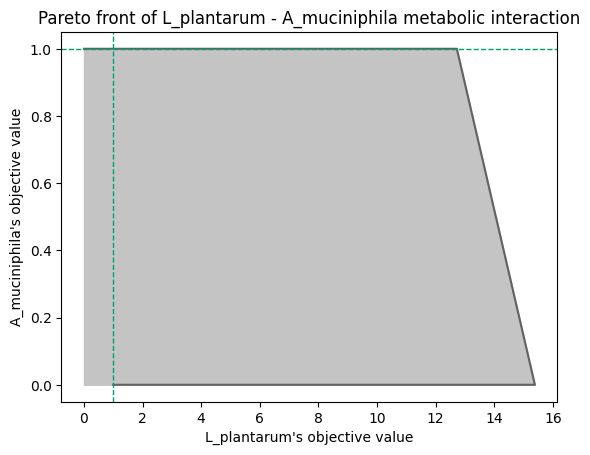

interaction score:  13.055735657972802
interaction type:  favors model1


In [3]:
int_score, int_type = analysis.interaction_score_and_type(model1, model2, Western_diet,
                                                          undescribed_metabolites_constraint="partially constrained",
                                                          plot = True)

print("interaction score: ",int_score)
print("interaction type: ",int_type)

In [4]:
model1_biomass_id = "Growth"
model2_biomass_id = "Growth"

potential_exchange = analysis.crossfed_metabolites(model1 = model1, model2 = model2, medium = Western_diet, undescribed_metabolites_constraint = "partially_constrained",
                               solver = "gurobi", model1_biomass_id = model1_biomass_id, model2_biomass_id = model2_biomass_id)


nb of bounds modified by medium :  193
(0, 1233)
(1, 2525)
/tmp/tmp6bdvf2te


/mnt/c/Users/tiago/matlab/finding_community_objective_functions/mimeco/lib/python3.13/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


In [22]:
potential_exchange

,metabolite_id,model_benefiting,proportion_exchange,proportion_model1_to_model2,proportion_model2_to_model1,correlation_obj_model1,correlation_obj_model2
0,glc__D,both,0.501499,0.501499,0.000000,0.887105,0.809449
1,pro__L,model2,0.847153,0.847153,0.000000,0.684568,0.811486
2,dha,model1,0.401598,0.000000,0.401598,0.856475,0.700481
3,lac__D,model1,0.970030,0.970030,0.000000,-0.934132,-0.647253
4,ser__D,model1,0.783217,0.210789,0.572428,0.865123,0.793235
5,ile__L,both,0.630370,0.172827,0.457542,0.843308,0.875360
6,val__L,model1,0.339660,0.000000,0.339660,0.828197,0.700619


In [6]:

metabolic_dict = utils.create_ecosystem_metabolic_dict(model1, model2)
with model1:
    model1, constrained_medium_dict1 = utils.restrain_medium(model1, Western_diet, undescribed_metabolites_constraint="partially constrained")
    solo_growth_model1 = model1.optimize().objective_value
with model2:
    model2, constrained_medium_dict2 = utils.restrain_medium(model2, Western_diet, undescribed_metabolites_constraint="partially constrained")
    solo_growth_model2 = model2.optimize().objective_value
print(solo_growth_model1, solo_growth_model2)
medium_dict = {**constrained_medium_dict1, **constrained_medium_dict2}
model1 = utils.unrestrain_medium(model1)
model2 = utils.unrestrain_medium(model2)
sol_mofba, ecosys = utils.mo_fba(model1, model2, metabolic_dict, medium_dict)
xy, maxi_model1, maxi_model2 = utils.pareto_parsing(sol_mofba, solo_growth_model1, solo_growth_model2)
cobra_ecosys = utils.mocba_to_cobra(ecosys)
sampling = utils.pareto_sampling(cobra_ecosys, xy, solo_growth_model1, solo_growth_model2, model1.id, model2.id, model1_biomass_id, model2_biomass_id, sample_size=10)
sampling

0.34379794714796735 0.9158429457946394
nb of bounds modified by medium :  45
(0, 1233)
(1, 2525)
/tmp/tmpv5cvc706


/mnt/c/Users/tiago/matlab/finding_community_objective_functions/mimeco/lib/python3.13/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


reactions,12DGR120tipp:L_plantarum,12DGR140tipp:L_plantarum,12DGR181tipp:L_plantarum,12PPDt:L_plantarum,23CAMPtex:L_plantarum,23CCMPtex:L_plantarum,23CGMPtex:L_plantarum,23CUMPtex:L_plantarum,23PDE2pp:L_plantarum,23PDE4pp:L_plantarum,...,EX_ppa_e:pool,EX_so4_e:pool,EX_salchs4_e:pool,EX_sbt__D_e:pool,EX_sulfac_e:pool,EX_tartr__D_e:pool,EX_thym_e:pool,EX_tma_e:pool,EX_tmao_e:pool,EX_tol_e:pool
-3.4379794714796736e-06_0.9158521042240975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-0.003847,0.0,0.0,0.0,-1.122947,0.0,0.0,0.0,0.0
1.0935878090528954_0.9158498146165842,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-0.222287,0.0,-24.813526,0.0,-77.129034,0.0,64.005542,-64.005542,0.0
2.1871790560852626_0.915847525009071,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-0.003847,0.0,0.0,0.0,-4.800756,0.0,0.0,0.0,0.0
3.2807703031176296_0.9158452354015577,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.244301,0.0,0.0,0.0,0.387697
4.374361550149996_0.9158429457940445,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5.29020449594404_0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.392585,0.0,0.0,0.0,0.0
4.30092387378072_-1.831685891589279e-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.232001,0.0,0.0,0.0,0.0
3.3116432516173995_-3.663371783178558e-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.178847,0.0,0.0,0.0,0.0
2.322362629454079_-5.495057674767837e-06,0.0,0.0,0.0,-0.161808,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1.3330820072907592_-7.326743566357116e-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [63]:
# print(cobra.util.solver.linear_reaction_coefficients(model1))
# print(cobra.util.solver.linear_reaction_coefficients(model2))
# print(sol_mofba.Primal)
# ecosys.sysreactions[-200:]
# model1.reactions
# print(len(model1.reactions)+len(model2.reactions))
# print(len(ecosys.sysreactions))
# xy

In [ ]:
def save_ecosys_to_mat(ecosys, sampling_df, filename="pairedModel_Bio_ATPM.mat"):
    cobra_ecosys = utils.mocba_to_cobra(ecosys)
    pairedModel = {
        'lb': np.array([r.lower_bound for r in cobra_ecosys.reactions], dtype=float).reshape(-1, 1),
        'ub': np.array([r.upper_bound for r in cobra_ecosys.reactions], dtype=float).reshape(-1, 1),
        'S': ecosys.Ssigma,
        'mets': np.array([m.id for m in cobra_ecosys.metabolites], dtype=object).reshape(-1, 1),
        'rxns': np.array([r.id for r in cobra_ecosys.reactions], dtype=object).reshape(-1, 1),
        'rxnNames': np.array([r.name for r in cobra_ecosys.reactions], dtype=object).reshape(-1, 1),
        'rxnFormulas': np.array([r.reaction for r in cobra_ecosys.reactions], dtype=object).reshape(-1, 1),
        'fluxes': sampling_df.values.T 
    }
    sio.savemat(filename, {'pairedModel': pairedModel})

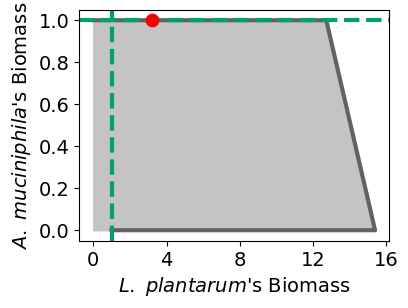

In [22]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

label1 = "$\\mathit{L.\\ plantarum}$'s Biomass"
label2 = "$\\mathit{A.\\ muciniphila}$'s Biomass"

# Funciton similar to pareto_plot from MIMECO utils but with adapted visuals and legends for poster
def pareto_plot_poster(xy, label1, label2, red_point=None):
    plt.figure(figsize=(4, 3))
    # plt.title("Pareto front of "+model1_id+" - "+model2_id+" metabolic interaction")
    plt.xlabel(label1, fontsize=14)
    plt.ylabel(label2, fontsize=14)
    plt.plot(xy['x'].to_numpy(), xy['y'].to_numpy(), '#626262ff', linestyle="-",linewidth=3)
    plt.fill_between(xy['x'].to_numpy(), xy['y'].to_numpy(), color = "#c4c4c4ff")
    plt.axhline(y = 1, color = '#009e73ff', linestyle = '--', linewidth = 3)
    plt.axvline(x = 1, color = '#009e73ff', linestyle = '--', linewidth = 3)

    if red_point is not None:
        plt.scatter(red_point[0], red_point[1], color='red', s=80, zorder=5)

    plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=5))
    plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=6))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    
import scipy.io
m = scipy.io.loadmat('pairedModel_Lacto_Akker.mat')['pairedModel'][0, 0]
idx = [i for i, r in enumerate(m['rxns'].flatten()) if "Growth" in str(r)]
pareto_plot_poster(xy, label1, label2, red_point=(m['fluxes'][idx[0], 1]/solo_growth_model1, m['fluxes'][idx[1], 1]/solo_growth_model2))

# pareto_plot_poster(xy,label1,label2)


In [12]:
sol_mofba.Primal

Primal(vertex_type=[0, 0, 1, 1], vertex_value=array([[-1.        ,  0.        ],
       [ 0.        , -1.        ],
       [ 4.37436155,  0.91584295],
       [ 5.2902045 ,  0.        ]]), adj=[[2, 1], [3, 0], [0, 3], [1, 2]], incidence=[[0, 1], [3, 1], [2, 0], [2, 3]], preimage=None)

In [58]:
save_ecosys_to_mat(ecosys, sampling, "pairedModel_Lacto_Akker.mat")